[Wiki example of SVD](https://en.wikipedia.org/wiki/Singular_value_decomposition#Example)

The following ⁠4×5⁠ matrix ⁠$\displaystyle \mathbf {M}$⁠ can be decomposed as $\displaystyle \mathbf {U\Sigma V} ^{*}$:

In [ ]:
import numpy as np

M = np.array([
    [4, 8, 8, 0, 0],
    [-3, -6, -6, 0, 0],
    [-4, 4, -2, 0, 0],
    [0, 0, 0, -4, 3]
])

U_EIG = np.linalg.eig(M @ M.T)
SIGMA = U_EIG.eigenvalues
idx = np.argsort(SIGMA)[::-1]
U = U_EIG.eigenvectors[:, idx]
SIGMA = SIGMA[idx]

SIGMA = np.sqrt(SIGMA)
SIGMA = np.diag(SIGMA)
SIGMA = np.pad(SIGMA, ((0, 0), (0, 1)))

V_EIG = np.linalg.eig(M.T @ M)
idx = np.argsort(V_EIG.eigenvalues)[::-1]
V = V_EIG.eigenvectors[:, idx].T
V = -1 * V

print('M = \n', M)
print()
print('U = \n', U)
print()
print('SIGMA = \n', SIGMA)
print()
print('V^T = \n', V)
print()
print('U * SIGMA * V = \n', U @ SIGMA @ V)

M = 
 [[ 4  8  8  0  0]
 [-3 -6 -6  0  0]
 [-4  4 -2  0  0]
 [ 0  0  0 -4  3]]

U = 
 [[ 0.8  0.   0.   0.6]
 [-0.6  0.   0.   0.8]
 [ 0.   1.   0.   0. ]
 [ 0.   0.   1.   0. ]]

SIGMA = 
 [[15.  0.  0.  0.  0.]
 [ 0.  6.  0.  0.  0.]
 [ 0.  0.  5.  0.  0.]
 [ 0.  0.  0.  0.  0.]]

V = 
 [[ 0.33333333  0.66666667  0.66666667 -0.         -0.        ]
 [-0.66666667  0.66666667 -0.33333333 -0.         -0.        ]
 [-0.         -0.         -0.         -0.8         0.6       ]
 [ 0.66666667  0.33333333 -0.66666667 -0.         -0.        ]
 [-0.         -0.         -0.         -0.6        -0.8       ]]

U * SIGMA * V = 
 [[ 4.  8.  8.  0.  0.]
 [-3. -6. -6.  0.  0.]
 [-4.  4. -2.  0.  0.]
 [ 0.  0.  0. -4.  3.]]



---

# Using numpy's library

In [4]:
import numpy as np

M = np.array([
    [4, 8, 8, 0, 0],
    [-3, -6, -6, 0, 0],
    [-4, 4, -2, 0, 0],
    [0, 0, 0, -4, 3]
])

U, singular, V_transpose = np.linalg.svd(M)

print("U = \n", U)
print()
print("singular = \n", singular)
print()
print("V^T = \n", V_transpose)

U = 
 [[ 0.8  0.   0.  -0.6]
 [-0.6  0.   0.  -0.8]
 [ 0.   1.   0.   0. ]
 [ 0.   0.   1.   0. ]]

singular = 
 [15.  6.  5.  0.]

V^T = 
 [[ 0.33333333  0.66666667  0.66666667 -0.          0.        ]
 [-0.66666667  0.66666667 -0.33333333  0.          0.        ]
 [ 0.          0.          0.         -0.8         0.6       ]
 [-0.66666667 -0.33333333  0.66666667  0.          0.        ]
 [ 0.          0.          0.          0.6         0.8       ]]



---

# Image approximation example

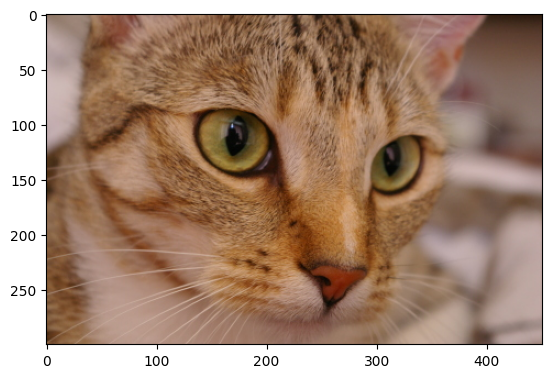

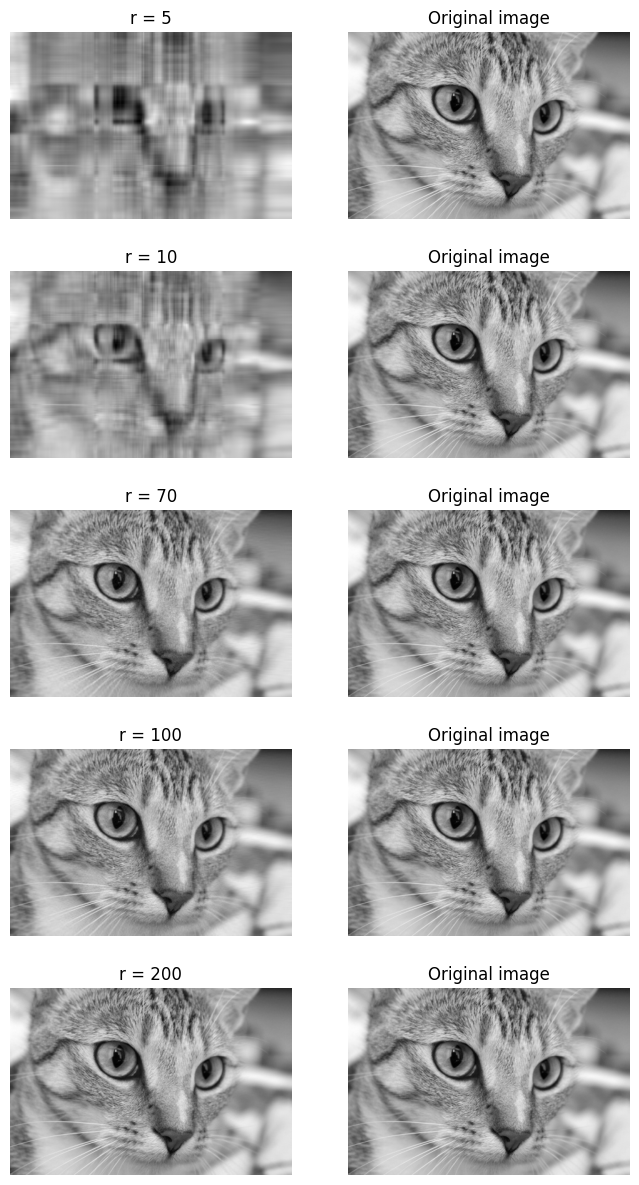

In [ ]:
from skimage import data, color
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import svd

cat = data.chelsea()
plt.imshow(cat)
gray_cat = color.rgb2gray(cat)

U, S, V_T = svd(gray_cat, full_matrices=False)
S = np.diag(S)
fig, ax = plt.subplots(5, 2, figsize=(8, 15))

curr_fig = 0
for r in [5, 10, 70, 100, 200]:
    cat_approx = U[:, :r] @ S[:r, :r] @ V_T[:r, :]
    ax[curr_fig][0].imshow(cat_approx, cmap='gray')
    ax[curr_fig][0].set_title('r = ' + str(r))
    ax[curr_fig, 0].axis('off')

    ax[curr_fig][1].imshow(gray_cat, cmap='gray')
    ax[curr_fig][1].set_title('Original image')
    ax[curr_fig, 1].axis('off')

    curr_fig += 1
plt.show()